In [2]:
# Load and display the data
import pandas as pd
file_path = "../Supporting Information 2_PlasticFADE.xlsx"  # CHECK: confirm file path
sheet_name = "Elena2023"
data = pd.read_excel(file_path, sheet_name=sheet_name, usecols='A,G:L', skiprows=1, nrows=15)
pd.set_option('display.float_format', '{:.2e}'.format)
print(data)

   Polymer & Size & Shape  k_fast [d-1]  k_medium [d-1]  k_slow [d-1]  \
0     PP, 1000 μm, Sphere      1.67e-04        2.70e-05      4.38e-06   
1      PP, 100 μm, Sphere      1.67e-03        2.70e-04      4.38e-05   
2       PP, 10 μm, Sphere      1.67e-02        2.70e-03      4.38e-04   
3     PS, 1000 μm, Sphere      2.19e-05        6.93e-07      2.19e-08   
4      PS, 100 μm, Sphere      2.19e-04        6.93e-06      2.19e-07   
5       PS, 10 μm, Sphere      2.19e-03        6.93e-05      2.19e-06   
6    PET, 1000 μm, Sphere      2.30e-03        7.10e-06      2.19e-08   
7     PET, 100 μm, Sphere      2.30e-02        7.10e-05      2.19e-07   
8      PET, 10 μm, Sphere      2.30e-01        7.10e-04      2.19e-06   
9   HDPE, 1000 μm, Sphere      2.63e-04        2.40e-06      2.19e-08   
10   HDPE, 100 μm, Sphere      2.63e-03        2.40e-05      2.19e-07   
11    HDPE, 10 μm, Sphere      2.63e-02        2.40e-04      2.19e-06   
12  LDPE, 1000 μm, Sphere      8.33e-04        4.27

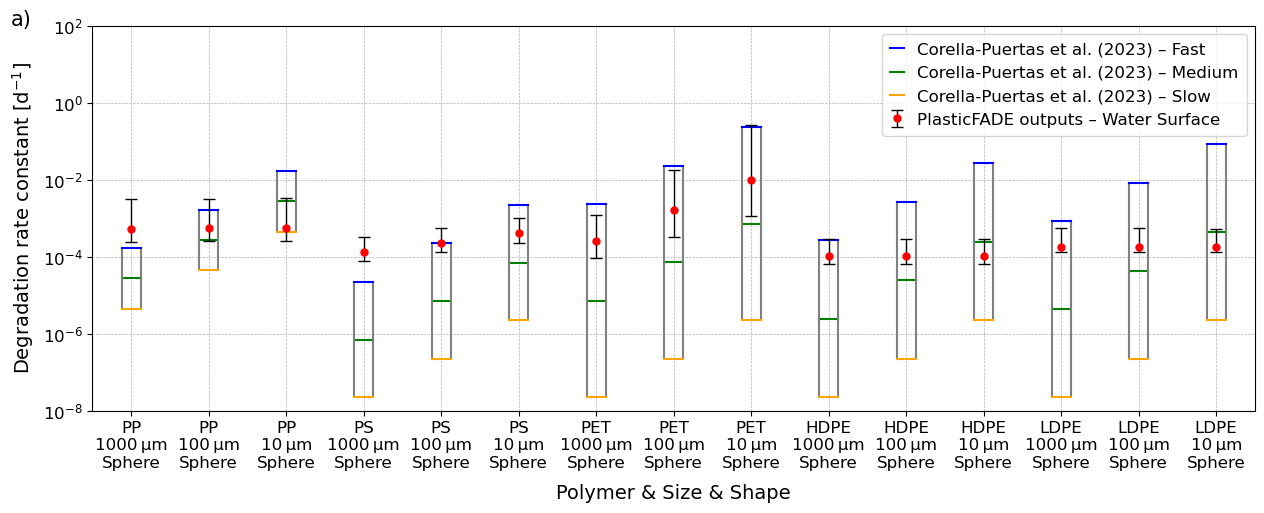

In [17]:
# Plot model outputs together with Elena's estimates
import matplotlib.pyplot as plt
import numpy as np

# Extract values & set up the plot
x = np.arange(len(data))
labels = data['Polymer & Size & Shape']
k_fast = data['k_fast [d-1]'].values
k_medium = data['k_medium [d-1]'].values
k_slow = data['k_slow [d-1]'].values
k_WS = data['k_WS [d-1]'].values
k_WS_LL = data['k_WS_LL [d-1]'].values
k_WS_UL = data['k_WS_UL [d-1]'].values
fig, ax = plt.subplots(figsize=(15, 5))
bar_width = 0.25

# Plot hollow boxes: lower (orange), upper (blue), with green shared boundary at k_medium
for i in range(len(x)):
    bottom1 = k_slow[i]
    mid = k_medium[i]
    top2 = k_fast[i]

    # Lower box: from k_slow to k_medium
    ax.plot([x[i] - bar_width / 2, x[i] - bar_width / 2], [bottom1, mid], color='grey')
    ax.plot([x[i] + bar_width / 2, x[i] + bar_width / 2], [bottom1, mid], color='grey')
    ax.plot([x[i] - bar_width / 2, x[i] + bar_width / 2], [bottom1, bottom1], color='orange')
    
    # Shared boundary at k_medium: green line
    ax.plot([x[i] - bar_width / 2, x[i] + bar_width / 2], [mid, mid], color='green')

    # Upper box: from k_medium to k_fast
    ax.plot([x[i] - bar_width / 2, x[i] - bar_width / 2], [mid, top2], color='grey')
    ax.plot([x[i] + bar_width / 2, x[i] + bar_width / 2], [mid, top2], color='grey')
    ax.plot([x[i] - bar_width / 2, x[i] + bar_width / 2], [top2, top2], color='blue')


# Plot k_WS with error bars
yerr = [k_WS - k_WS_LL, k_WS_UL - k_WS]
errorbar_plot = ax.errorbar(x, k_WS, yerr=yerr, fmt='o', color='red', ecolor='black',
            elinewidth=1, capsize=4, markersize=5, label='PlasticFADE outputs – Water Surface')

# Show the outliers (outside the plot boundary)
y_max = 1e+2
label_y = y_max * 10**0.3  # X% above the plot top
for i in range(len(x)):
    upper = data['k_WS_UL [d-1]'].iloc[i]
    if upper > y_max:
        label = f"{upper:.1e}".replace("+", "")

        ax.plot(
            [i, i],              # x-coordinates
            [y_max, label_y],    # from plot top to label
            color='grey',
            linewidth=1,
            linestyle=':',
            clip_on=False
        )       

        # Draw text label
        ax.text(
            i, label_y,
            label,
            ha='center',
            va='bottom',
            color='grey',
            # fontsize=9,
            clip_on=False
        )

# Axes formatting
ax.set_xticks(x)
labels = data['Polymer & Size & Shape'].str.replace(', ', '\n').str.replace(' ', '\u2009')
ax.set_xticklabels(labels)
ax.set_xlabel('Polymer & Size & Shape', labelpad=10, fontsize=14)
ax.set_yscale('log')
ax.set_ylabel('Degradation rate constant [d$^{-1}$]', labelpad=5, fontsize=14)
ax.tick_params(axis='both', which='major', labelsize=12)
plt.xlim(-0.5, len(x) - 0.5)  # Pull the first and last data points closer to the edge of the plot
plt.ylim(1e-8, 1e+2)  # Set y-axis limits manually
plt.grid(True, which="major", ls="--", lw=0.5)

# Custom legend handles
import matplotlib.lines as mlines
handles = [
    mlines.Line2D([], [], color='blue', label='Corella-Puertas et al. (2023) – Fast'),
    mlines.Line2D([], [], color='green', label='Corella-Puertas et al. (2023) – Medium'),
    mlines.Line2D([], [], color='orange', label='Corella-Puertas et al. (2023) – Slow'),
]
all_handles = handles + [errorbar_plot]
ax.legend(handles=all_handles, handlelength=0.8, borderpad=0.5, loc='upper right', fontsize=12)
plt.text(-0.07, 1.0, "a)", transform=plt.gca().transAxes, fontsize=15, fontweight='normal')
plt.savefig("../Figures/Figure_4a.png", dpi=600, bbox_inches='tight')  # CHECK: confirm name and desired place for the plot
plt.show()

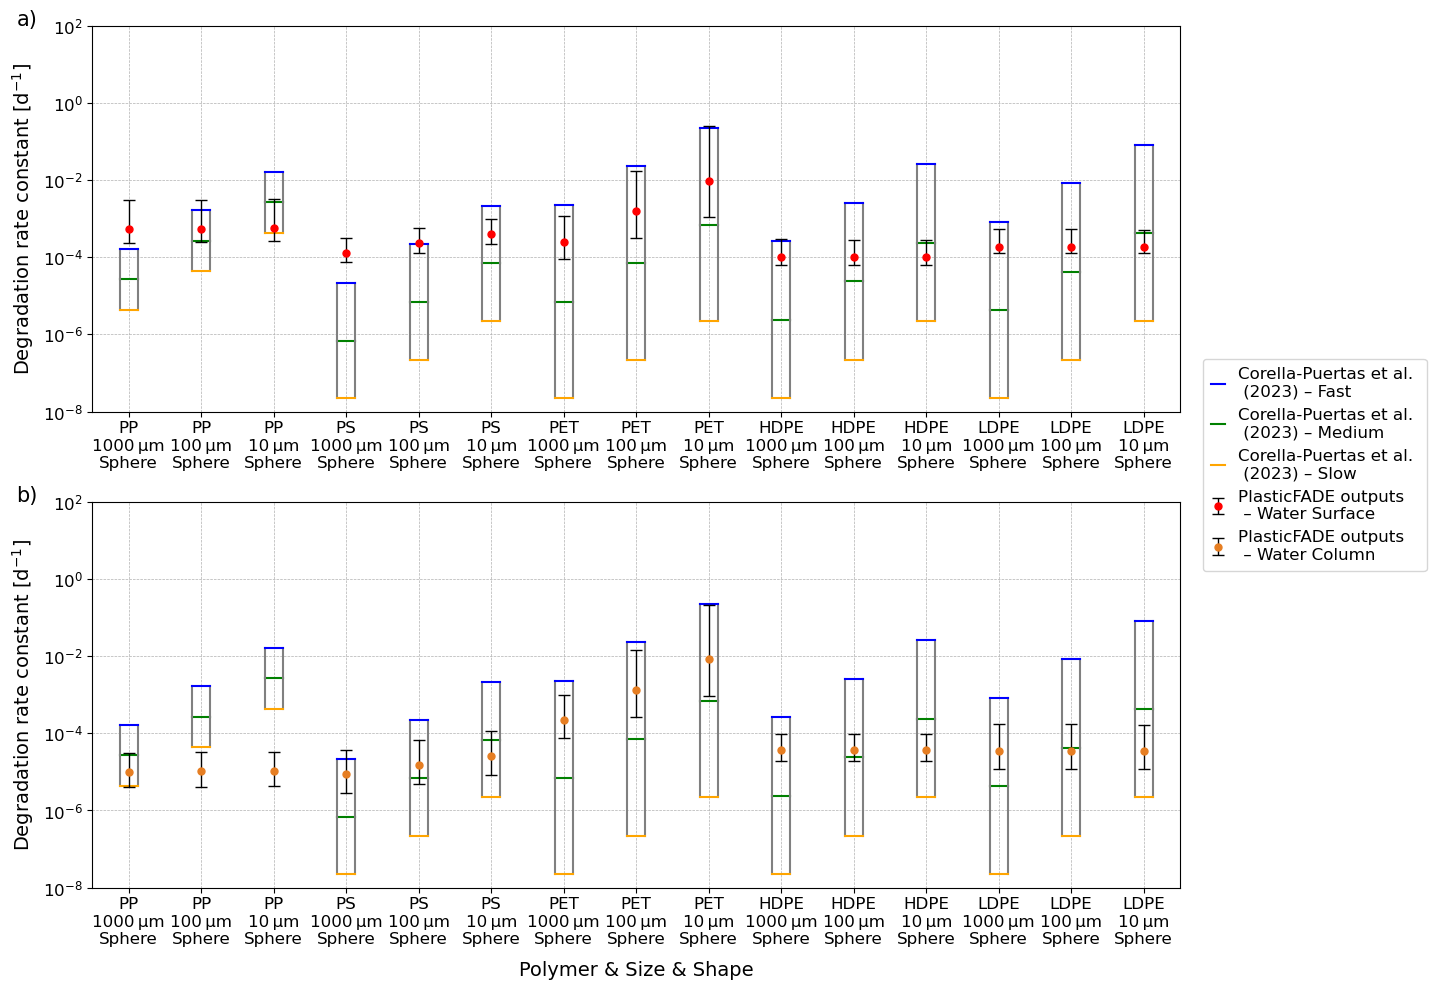

In [38]:
# Load and display the data
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import numpy as np

file_path = "../Supporting Information 2_PlasticFADE.xlsx"

# Load data for Water Surface
data_ws = pd.read_excel(file_path, sheet_name="Elena2023", usecols='A,G:L', skiprows=1, nrows=15)

# Load data for Water Column
data_wc = pd.read_excel(file_path, sheet_name="Elena2023", usecols='A,G:I,M:O', skiprows=1, nrows=15)

pd.set_option('display.float_format', '{:.2e}'.format)

# Create figure with two subplots stacked vertically
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))
bar_width = 0.25

# =============================================
# TOP SUBPLOT: Water Surface
# =============================================
x1 = np.arange(len(data_ws))

k_fast_ws = data_ws['k_fast [d-1]'].values
k_medium_ws = data_ws['k_medium [d-1]'].values
k_slow_ws = data_ws['k_slow [d-1]'].values
k_WS = data_ws['k_WS [d-1]'].values
k_WS_LL = data_ws['k_WS_LL [d-1]'].values
k_WS_UL = data_ws['k_WS_UL [d-1]'].values

# Plot hollow boxes
for i in range(len(x1)):
    bottom1 = k_slow_ws[i]
    mid = k_medium_ws[i]
    top2 = k_fast_ws[i]

    ax1.plot([x1[i] - bar_width / 2, x1[i] - bar_width / 2], [bottom1, mid], color='grey')
    ax1.plot([x1[i] + bar_width / 2, x1[i] + bar_width / 2], [bottom1, mid], color='grey')
    ax1.plot([x1[i] - bar_width / 2, x1[i] + bar_width / 2], [bottom1, bottom1], color='orange')
    ax1.plot([x1[i] - bar_width / 2, x1[i] + bar_width / 2], [mid, mid], color='green')
    ax1.plot([x1[i] - bar_width / 2, x1[i] - bar_width / 2], [mid, top2], color='grey')
    ax1.plot([x1[i] + bar_width / 2, x1[i] + bar_width / 2], [mid, top2], color='grey')
    ax1.plot([x1[i] - bar_width / 2, x1[i] + bar_width / 2], [top2, top2], color='blue')

# Plot k_WS with error bars
yerr_ws = [k_WS - k_WS_LL, k_WS_UL - k_WS]
errorbar_plot_ws = ax1.errorbar(x1, k_WS, yerr=yerr_ws, fmt='o', color='red', ecolor='black',
            elinewidth=1, capsize=4, markersize=5, label='PlasticFADE outputs \n – Water Surface')

# Show outliers
y_max = 1e+2
label_y = y_max * 10**0.3
for i in range(len(x1)):
    upper = data_ws['k_WS_UL [d-1]'].iloc[i]
    if upper > y_max:
        label = f"{upper:.1e}".replace("+", "")
        ax1.plot([i, i], [y_max, label_y], color='grey', linewidth=1, linestyle=':', clip_on=False)
        ax1.text(i, label_y, label, ha='center', va='bottom', color='grey', clip_on=False)

# Axes formatting
ax1.set_xticks(x1)
labels_ws = data_ws['Polymer & Size & Shape'].str.replace(', ', '\n').str.replace(' ', '\u2009')
ax1.set_xticklabels(labels_ws)
ax1.set_ylabel('Degradation rate constant [d$^{-1}$]', labelpad=5, fontsize=14)
ax1.tick_params(axis='both', which='major', labelsize=12)
ax1.set_xlim(-0.5, len(x1) - 0.5)
ax1.set_ylim(1e-8, 1e+2)
ax1.set_yscale('log')
ax1.grid(True, which="major", ls="--", lw=0.5)
ax1.text(-0.07, 1.0, "a)", transform=ax1.transAxes, fontsize=15, fontweight='normal')

# =============================================
# BOTTOM SUBPLOT: Water Column
# =============================================
x2 = np.arange(len(data_wc))

k_fast_wc = data_wc['k_fast [d-1]'].values
k_medium_wc = data_wc['k_medium [d-1]'].values
k_slow_wc = data_wc['k_slow [d-1]'].values
k_WC = data_wc['k_WC [d-1]'].values
k_WC_LL = data_wc['k_WC_LL [d-1]'].values
k_WC_UL = data_wc['k_WC_UL [d-1]'].values

# Plot hollow boxes
for i in range(len(x2)):
    bottom1 = k_slow_wc[i]
    mid = k_medium_wc[i]
    top2 = k_fast_wc[i]

    ax2.plot([x2[i] - bar_width / 2, x2[i] - bar_width / 2], [bottom1, mid], color='grey')
    ax2.plot([x2[i] + bar_width / 2, x2[i] + bar_width / 2], [bottom1, mid], color='grey')
    ax2.plot([x2[i] - bar_width / 2, x2[i] + bar_width / 2], [bottom1, bottom1], color='orange')
    ax2.plot([x2[i] - bar_width / 2, x2[i] + bar_width / 2], [mid, mid], color='green')
    ax2.plot([x2[i] - bar_width / 2, x2[i] - bar_width / 2], [mid, top2], color='grey')
    ax2.plot([x2[i] + bar_width / 2, x2[i] + bar_width / 2], [mid, top2], color='grey')
    ax2.plot([x2[i] - bar_width / 2, x2[i] + bar_width / 2], [top2, top2], color='blue')

# Plot k_WC with error bars
yerr_wc = [k_WC - k_WC_LL, k_WC_UL - k_WC]
errorbar_plot_wc = ax2.errorbar(x2, k_WC, yerr=yerr_wc, fmt='o', color='#E67E22', ecolor='black',
            elinewidth=1, capsize=4, markersize=5, label='PlasticFADE outputs \n – Water Column')

# Show outliers
y_max = 1e2
label_y = y_max * 10**0.3
for i in range(len(x2)):
    upper = data_wc['k_WC_UL [d-1]'].iloc[i]
    if upper > y_max:
        label = f"{upper:.1e}"
        ax2.plot([i, i], [y_max, label_y], color='grey', linewidth=1, linestyle=':', clip_on=False)
        ax2.text(i, label_y, label, ha='center', va='bottom', color='grey', clip_on=False)

# Axes formatting
ax2.set_xticks(x2)
labels_wc = data_wc['Polymer & Size & Shape'].str.replace(', ', '\n').str.replace(' ', '\u2009')
ax2.set_xticklabels(labels_wc)
ax2.set_xlabel('Polymer & Size & Shape', labelpad=10, fontsize=14)
ax2.set_ylabel('Degradation rate constant [d$^{-1}$]', labelpad=5, fontsize=14)
ax2.tick_params(axis='both', which='major', labelsize=12)
ax2.set_xlim(-0.5, len(x2) - 0.5)
ax2.set_ylim(1e-8, 1e2)
ax2.set_yscale('log')
ax2.grid(True, which="major", ls="--", lw=0.5)
ax2.text(-0.07, 1.0, "b)", transform=ax2.transAxes, fontsize=15, fontweight='normal')

# =============================================
# Single legend on the right
# =============================================
handles = [
    mlines.Line2D([], [], color='blue', label='Corella-Puertas et al. \n (2023) – Fast'),
    mlines.Line2D([], [], color='green', label='Corella-Puertas et al. \n (2023) – Medium'),
    mlines.Line2D([], [], color='orange', label='Corella-Puertas et al. \n (2023) – Slow'),
    errorbar_plot_ws,
    errorbar_plot_wc
]
fig.legend(handles=handles, handlelength=0.8, borderpad=0.5, loc='center right', fontsize=12, bbox_to_anchor=(1.20, 0.53))

plt.tight_layout()
plt.savefig("../Figures/Figure_4_combined.png", dpi=600, bbox_inches='tight')
plt.show()